<a href="https://colab.research.google.com/github/sm1ley68/telco-churn-prediction/blob/main/telco_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print("Размер:", df.shape)
df.head()

Размер: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
print(df['Churn'].value_counts())
print()
print(df['Churn'].value_counts(normalize=True))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64


In [5]:
# Пытаемся превратить в число; что не сможет — станет NaN
tc_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
print("Не распарсилось:", tc_numeric.isna().sum())
df[tc_numeric.isna()][['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]

Не распарсилось: 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,
753,3115-CZMZD,0,20.25,
936,5709-LVOEQ,0,80.85,
1082,4367-NUYAO,0,25.75,
1340,1371-DWPAZ,0,56.05,
3331,7644-OMVMY,0,19.85,
3826,3213-VVOLG,0,25.35,
4380,2520-SGTTA,0,20.00,
5218,2923-ARZLG,0,19.70,
6670,4075-WKNIU,0,73.35,


In [6]:
# Превращаем в число (пробелы станут NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Заполняем пропуски нулём (это новые клиенты, tenure=0)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Проверяем
print("Тип теперь:", df['TotalCharges'].dtype)
print("Пропусков осталось:", df['TotalCharges'].isna().sum())

Тип теперь: float64
Пропусков осталось: 0


Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


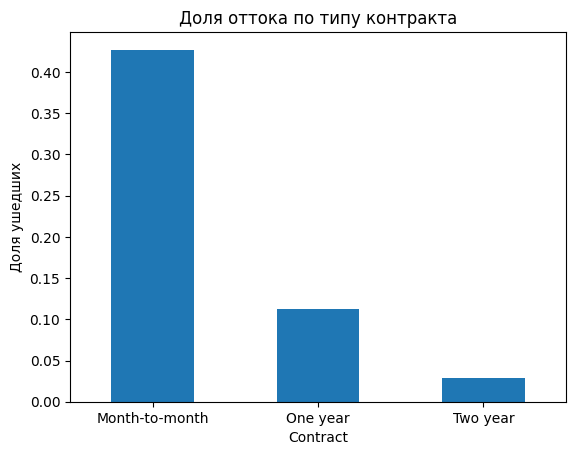

In [7]:
import matplotlib.pyplot as plt

# Доля ушедших внутри каждого типа контракта
churn_by_contract = df.groupby('Contract')['Churn'].apply(lambda x: (x == 'Yes').mean())
print(churn_by_contract)

# График
churn_by_contract.plot(kind='bar', title='Доля оттока по типу контракта')
plt.ylabel('Доля ушедших')
plt.xticks(rotation=0)
plt.show()

Churn
No     37.569965
Yes    17.979133
Name: tenure, dtype: float64



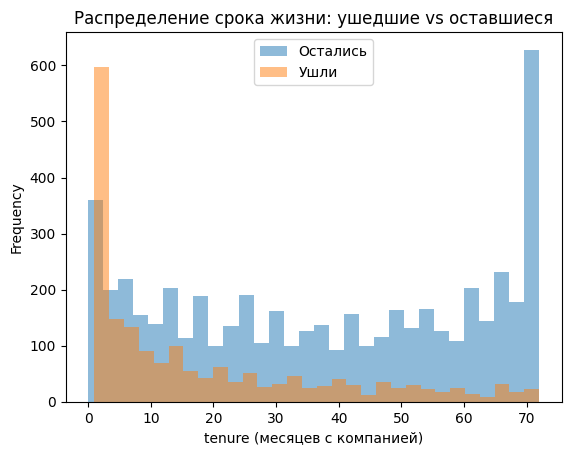

In [8]:
# Средний tenure у ушедших и оставшихся
print(df.groupby('Churn')['tenure'].mean())
print()

# Распределения — две гистограммы
df[df['Churn']=='No']['tenure'].plot(kind='hist', bins=30, alpha=0.5, label='Остались', legend=True)
df[df['Churn']=='Yes']['tenure'].plot(kind='hist', bins=30, alpha=0.5, label='Ушли', legend=True)
plt.xlabel('tenure (месяцев с компанией)')
plt.title('Распределение срока жизни: ушедшие vs оставшиеся')
plt.show()

In [9]:
# 1. Таргет: Yes -> 1, No -> 0
df['Churn'] = (df['Churn'] == 'Yes').astype(int)

# 2. Убираем бесполезный для модели customerID (это просто идентификатор)
df_model = df.drop('customerID', axis=1)

# 3. One-hot для всех категориальных признаков
df_model = pd.get_dummies(df_model, drop_first=True)

print("Размер до:", df.shape)
print("Размер после one-hot:", df_model.shape)
df_model.head()

Размер до: (7043, 21)
Размер после one-hot: (7043, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X = df_model.drop('Churn', axis=1)
y = df_model['Churn']

# stratify=y — сохраняем пропорцию классов (26.5% / 73.5%) и в train, и в test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Доля ушедших в train:", y_train.mean().round(4))
print("Доля ушедших в test:", y_test.mean().round(4))

Train: (5634, 30) Test: (1409, 30)
Доля ушедших в train: 0.2654
Доля ушедших в test: 0.2654


In [13]:
from sklearn.dummy import DummyClassifier

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)

dummy_acc = accuracy_score(y_test, dummy.predict(X_test))
print("Accuracy baseline:", round(dummy_acc, 4))

Accuracy baseline: 0.7346


In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy baseline:", round(dummy_acc, 4))
print("Accuracy RandomForest:   ", round(accuracy_score(y_test, y_pred), 4))
print()
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy baseline: 0.7346
Accuracy RandomForest:    0.785

Confusion matrix:
[[920 115]
 [188 186]]


In [16]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", round(precision_score(y_test, y_pred), 4))
print("Recall:   ", round(recall_score(y_test, y_pred), 4))
print("F1:       ", round(f1_score(y_test, y_pred), 4))

Precision: 0.6179
Recall:    0.4973
F1:        0.5511


In [17]:
# Вероятности ухода (а не метки) для тестовых клиентов
y_proba = rf.predict_proba(X_test)[:, 1]

# Сравним два порога: стандартный 0.5 и пониженный 0.3
for threshold in [0.5, 0.3]:
    y_pred_t = (y_proba >= threshold).astype(int)
    print(f"--- Порог {threshold} ---")
    print("Recall:   ", round(recall_score(y_test, y_pred_t), 4))
    print("Precision:", round(precision_score(y_test, y_pred_t), 4))
    print()

--- Порог 0.5 ---
Recall:    0.508
Precision: 0.6149

--- Порог 0.3 ---
Recall:    0.746
Precision: 0.5225



In [18]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_proba)
print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.8253


In [19]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf, X, y, cv=cv, scoring='roc_auc')

print("ROC-AUC на каждом из 5 фолдов:", scores.round(4))
print("Среднее:", round(scores.mean(), 4))
print("Стандартное отклонение:", round(scores.std(), 4))

ROC-AUC на каждом из 5 фолдов: [0.8317 0.8213 0.8338 0.8024 0.8191]
Среднее: 0.8217
Стандартное отклонение: 0.0112


In [20]:
features = ['tenure', 'MonthlyCharges', 'TotalCharges']
df[features].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304
std,24.559481,30.090047,2266.794470
min,0.000000,18.250000,0.000000
25%,9.000000,35.500000,398.550000
50%,29.000000,70.350000,1394.550000
75%,55.000000,89.850000,3786.600000
max,72.000000,118.750000,8684.800000


In [21]:
from sklearn.preprocessing import StandardScaler

X_cluster = df[features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# Проверим: после масштабирования mean≈0, std≈1 у всех признаков
X_scaled_df = pd.DataFrame(X_scaled, columns=features)
print(X_scaled_df.describe().round(2))

        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     -0.00           -0.00         -0.00
std       1.00            1.00          1.00
min      -1.32           -1.55         -1.01
25%      -0.95           -0.97         -0.83
50%      -0.14            0.19         -0.39
75%       0.92            0.83          0.66
max       1.61            1.79          2.83


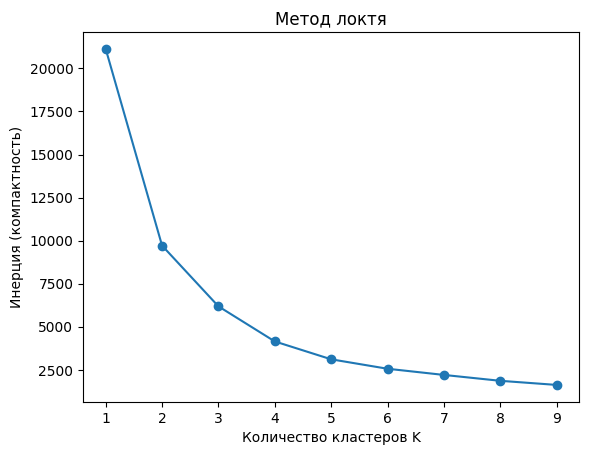

K=1: инерция = 21129
K=2: инерция = 9712
K=3: инерция = 6186
K=4: инерция = 4148
K=5: инерция = 3111
K=6: инерция = 2563
K=7: инерция = 2204
K=8: инерция = 1863
K=9: инерция = 1624


In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []
K_range = range(1, 10)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(K_range, inertias, marker='o')
plt.xlabel('Количество кластеров K')
plt.ylabel('Инерция (компактность)')
plt.title('Метод локтя')
plt.show()

for k, inert in zip(K_range, inertias):
    print(f"K={k}: инерция = {round(inert)}")

In [23]:
from sklearn.metrics import silhouette_score

for k in [2, 3, 4, 5]:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    sil = silhouette_score(X_scaled, labels)
    print(f"K={k}: силуэт = {round(sil, 4)}")

K=2: силуэт = 0.4797
K=3: силуэт = 0.4515
K=4: силуэт = 0.4722
K=5: силуэт = 0.4437


In [24]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X_scaled)

# Портрет каждого сегмента: средние по признакам + размер + доля оттока
profile = df.groupby('cluster').agg(
    size=('cluster', 'size'),
    tenure=('tenure', 'mean'),
    MonthlyCharges=('MonthlyCharges', 'mean'),
    TotalCharges=('TotalCharges', 'mean'),
    churn_rate=('Churn', 'mean')
).round(2)

print(profile)

         size  tenure  MonthlyCharges  TotalCharges  churn_rate
cluster                                                        
0        1703   10.21           31.78        302.15        0.25
1        1904   59.53           93.31       5548.65        0.15
2        2276   15.42           80.78       1251.17        0.48
3        1160   53.57           34.91       1835.62        0.05


In [25]:
import joblib
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Компактный набор признаков для приложения
feat_num = ['tenure', 'MonthlyCharges']
feat_cat = ['Contract', 'InternetService']
features_app = feat_num + feat_cat

X_app = df[features_app]
y_app = df['Churn']

# One-hot только для категориальных, числовые пропускаем как есть
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), feat_cat)
], remainder='passthrough')

pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

pipe.fit(X_app, y_app)

# Замораживаем в файл
joblib.dump(pipe, 'churn_model.joblib')
print("Модель сохранена. Проверка предсказания на первом клиенте:")
print("Вероятность ухода:", round(pipe.predict_proba(X_app.iloc[[0]])[0][1], 4))

Модель сохранена. Проверка предсказания на первом клиенте:
Вероятность ухода: 0.13


In [26]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for metric in ['roc_auc', 'recall', 'precision']:
    scores = cross_val_score(pipe, X_app, y_app, cv=cv, scoring=metric)
    print(f"{metric}: {round(scores.mean(), 4)} ± {round(scores.std(), 4)}")

roc_auc: 0.7868 ± 0.0096
recall: 0.4869 ± 0.0102
precision: 0.5587 ± 0.0223


In [27]:
# Расширенный набор: добавили TechSupport, OnlineSecurity, PaymentMethod, PaperlessBilling
feat_num = ['tenure', 'MonthlyCharges']
feat_cat = ['Contract', 'InternetService', 'TechSupport', 'OnlineSecurity',
            'PaymentMethod', 'PaperlessBilling']
features_app = feat_num + feat_cat

X_app = df[features_app]
y_app = df['Churn']

preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), feat_cat)
], remainder='passthrough')

pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42, class_weight='balanced'))
])

# Проверим качество кросс-валидацией
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for metric in ['roc_auc', 'recall', 'precision']:
    scores = cross_val_score(pipe, X_app, y_app, cv=cv, scoring=metric)
    print(f"{metric}: {round(scores.mean(), 4)} ± {round(scores.std(), 4)}")

roc_auc: 0.8014 ± 0.0082
recall: 0.4896 ± 0.013
precision: 0.5827 ± 0.0138


In [28]:
from sklearn.model_selection import cross_val_predict

# Вероятности через кросс-валидацию (честная оценка)
y_proba_cv = cross_val_predict(pipe, X_app, y_app, cv=cv, method='predict_proba')[:, 1]

from sklearn.metrics import recall_score, precision_score
for t in [0.5, 0.4, 0.35, 0.3]:
    pred = (y_proba_cv >= t).astype(int)
    print(f"Порог {t}: recall={round(recall_score(y_app, pred),3)}, precision={round(precision_score(y_app, pred),3)}")

Порог 0.5: recall=0.495, precision=0.579
Порог 0.4: recall=0.57, precision=0.54
Порог 0.35: recall=0.622, precision=0.521
Порог 0.3: recall=0.667, precision=0.503


In [29]:
%%writefile app.py
import streamlit as st
import pandas as pd
import joblib

model = joblib.load('churn_model.joblib')
THRESHOLD = 0.3  # снижен ради recall: ловим больше уходящих (см. README)

st.title('Прогноз оттока клиента')
st.write('Введите данные клиента — модель оценит вероятность ухода.')

col1, col2 = st.columns(2)
with col1:
    tenure = st.slider('Месяцев с компанией', 0, 72, 12)
    monthly = st.slider('Месячный платёж ($)', 18, 120, 65)
    contract = st.selectbox('Контракт', ['Month-to-month', 'One year', 'Two year'])
    internet = st.selectbox('Интернет', ['DSL', 'Fiber optic', 'No'])
with col2:
    techsup = st.selectbox('Тех. поддержка', ['No', 'Yes', 'No internet service'])
    security = st.selectbox('Онлайн-защита', ['No', 'Yes', 'No internet service'])
    payment = st.selectbox('Способ оплаты', ['Electronic check', 'Mailed check',
                           'Bank transfer (automatic)', 'Credit card (automatic)'])
    paperless = st.selectbox('Безбумажный счёт', ['Yes', 'No'])

if st.button('Предсказать'):
    X_new = pd.DataFrame([{
        'tenure': tenure, 'MonthlyCharges': monthly,
        'Contract': contract, 'InternetService': internet,
        'TechSupport': techsup, 'OnlineSecurity': security,
        'PaymentMethod': payment, 'PaperlessBilling': paperless
    }])
    proba = model.predict_proba(X_new)[0][1]
    st.metric('Вероятность ухода', f'{proba:.1%}')
    if proba >= THRESHOLD:
        st.error(f'Высокий риск (порог {THRESHOLD:.0%}) — клиента стоит удерживать.')
    else:
        st.success('Низкий риск оттока.')
    st.caption('Порог снижен до 30% намеренно: в задаче удержания '
               'пропустить уходящего дороже, чем ложная тревога.')

Writing app.py


In [30]:
pipe.fit(X_app, y_app)
joblib.dump(pipe, 'churn_model.joblib')
print("Модель на 8 признаках пересохранена.")

Модель на 8 признаках пересохранена.


In [32]:
%%writefile requirements.txt
streamlit
pandas
scikit-learn
joblib

Writing requirements.txt
